# STCS Tutorial: Spatial Transcriptomics Cell Segmentation

This tutorial is used torun the complete STCS pipeline based on the merged `STCS_main.py` module. 

The pipeline includes:

1. **Data Preparation**: Loading and cropping spatial data

2. **Cell Segmentation**: Segmentation pipeline for nucleus detection

3. **Pseudobulk Creation**: Aggregating spots into cell-level data

4. **Parameter Tuning**: Optimizing search radius for assignment

5. **PCA Assignment**: Gene space assignment with reference data

6. **Cell Type Annotation**: CellTypist-based annotation

7. **Visualization**: Spatial plotting of results

8. **Method Comparison**: Comparing different assignment methods

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import squidpy as sq


# Import the STCS module
sys.path.append("../STCS")
from STCS_main import STCS 

# For visualization
import plotly.graph_objects as go
import plotly.express as px
from plotly.offline import plot
from matplotlib.colors import ListedColormap

/home/xh300/.conda/envs/sq/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/xh300/.conda/envs/sq/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/xh300/.conda/envs/sq/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/xh300/.conda/envs/sq/

# Set up paths

In [2]:
# Define data type
PLATFORM ="Visium" 
# Should contain filtered_feature_bc_matrix.h5 and spatial folder
FOLDER_PATH = '/home/xh300/link/spa/sthd/STHD/ground_truth/visium2_postX/binned_outputs/square_002um'
# Full resolution H&E image
FULL_RES_IMAGE_PATH = '/home/xh300/link/spa/sthd/STHD/ground_truth/visium2_postX/Xenium_Prime_Human_Lung_Cancer_FFPE_he_image.ome.tif'
# Single-cell reference for annotation
SC_REF_PATH = '/home/xh300/link/spa/sthd/STHD/ground_truth/ref/897e76b2-59f6-482c-827d-37cc62fa4f50.h5ad'
# CellTypist model directory
MODEL_PATH = '/home/xh300/link/spa/sthd/STHD/ground_truth/ref/LungCancerModel.pkl'

In [ ]:
# Output directorys
RESULTS_PATH = "/home/xh300/link/spa/newmethod/L=0.5,S=1"
# Create results directory
os.makedirs(RESULTS_PATH, exist_ok=True)

# 1. Data Preparation and Loading

Start by loading the full spatial transcriptomics dataset and cropping a region of interest for faster processing.

## Load full data

In [4]:
import PIL
PIL.Image.MAX_IMAGE_PIXELS = 10000000+2737977046 

In [5]:
# Load the full dataset
full_data = STCS(
    Folder_path=FOLDER_PATH,
    counts_data="filtered_feature_bc_matrix.h5",
    full_res_image_path=FULL_RES_IMAGE_PATH,
    sc_ref=SC_REF_PATH,
    model_path=MODEL_PATH,
    Platform = PLATFORM
)

[Log]: Loaded Visium data
[Log]: source_image_path set in metadata: /lab01/xh300/spa/sthd/STHD/ground_truth/visium2_postX/Xenium_Prime_Human_Lung_Cancer_FFPE_he_image.ome.tif
[Log]: Found spatial info
[Log]: STCS loaded: 6535116 spots, 18085 genes


In [6]:
x1, x2, y1, y2 = full_data.get_sequencing_data_region()
print(f"Data region bounds: x=({x1}, {x2}), y=({y1}, {y2})")

Data region bounds: x=(-5827, 18439), y=(-290, 24507)


## Crop

[Log]: Loaded full image | Shape: (43270, 26720, 3) | Dtype: uint8


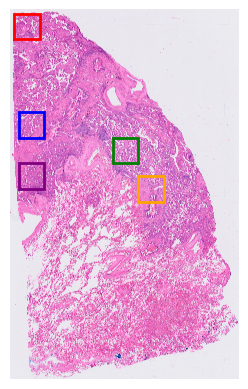

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

full_img = full_data.load_img()
if full_img is None:
    raise RuntimeError("Cropped image could not be loaded!")

plt.imshow(full_img)
plt.axis("off")

ax = plt.gca()

# 定义矩形 (x, y, width, height)
rects = [
    (500, 500, 3000, 3000),
    (1000, 12000, 3000, 3000),
    (12000, 15000, 3000, 3000),
    (15000, 19500, 3000, 3000),
    (1000, 18000, 3000, 3000)
]

# 定义颜色列表（可以随便扩展）
colors = ["red", "blue", "green", "orange", "purple"]

# 循环画框
for (x, y, w, h), c in zip(rects, colors):
    rect = patches.Rectangle(
        (x, y), w, h,
        linewidth=2, edgecolor=c, facecolor="none"
    )
    ax.add_patch(rect)

plt.savefig("spatial.pdf", bbox_inches="tight")
plt.show()
plt.close()

In [8]:
# Crop a region of interest for faster processing
# Adjust these coordinates based on your data

crop_x1 = rects[4][0]
crop_y1 = rects[4][1]
crop_size = 3000  # 5000x5000 pixel region

crop_x2 = crop_x1 + crop_size
crop_y2 = crop_y1 + crop_size

print(f"Cropping region: ({crop_x1}, {crop_y1}) to ({crop_x2}, {crop_y2})")

Cropping region: (1000, 18000) to (4000, 21000)


[Log]: Cropped region aligned to 0, 0, 2999, 2999
[Log]: Cropped from 6535116 to 168691 spots
[Log]: Returning cropped image from memory.


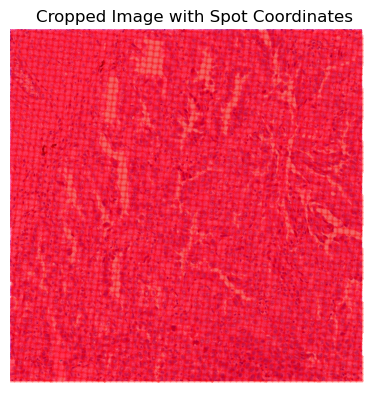

In [9]:
# Apply crop
crop_data = full_data.crop(crop_x1,crop_x2,crop_y1, crop_y2,1)
if crop_data is None:
    raise RuntimeError("Cropping failed!")

#  Load cropped image
crop_img = crop_data.load_img()
if crop_img is None:
    raise RuntimeError("Cropped image could not be loaded!")

#  Visualize cropped image and spatial coordinates
plt.imshow(crop_img)
spatial = crop_data.adata.obsm["spatial"]
plt.scatter(spatial[:, 0], spatial[:, 1], s=0.05, c="red", alpha = 0.5)
plt.title("Cropped Image with Spot Coordinates")
plt.axis("off")
plt.show()

## Display the cropped H&E image

[Log]: Returning cropped image from memory.


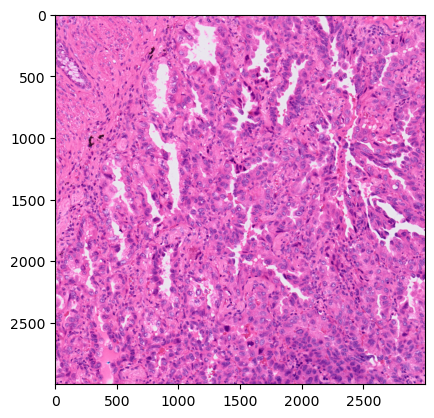

In [10]:
crop_img = crop_data.load_img()
plt.imshow(crop_img)

## Save the cropped data

In [11]:
crop_data.save(RESULTS_PATH)

... storing 'feature_types' as categorical
... storing 'genome' as categorical


... storing 'feature_types' as categorical
... storing 'genome' as categorical


[Log]: STCS data saved to /home/xh300/link/spa/newmethod/L=0.5,S=4/gt_crop5


# 2. Cell Segmentation

Next, we perform cell segmentation

In [12]:
# load the cropped data so that we could skip the cropping step in future runs
crop_data = STCS.from_saved(RESULTS_PATH)

[Log]: Loaded cropped image from /home/xh300/link/spa/newmethod/L=0.5,S=4/gt_crop5/cropped_image.tif
[Log]: STCS loaded raw data from /home/xh300/link/spa/newmethod/L=0.5,S=4/gt_crop5: 168691 spots, 18085 genes


## Segmentation

In [13]:
crop_data_segmented = crop_data.run_stardist_pipeline(
    RESULTS_PATH,
    prob_thresh=0.1,
    factor = 1)

[Log]: Starting stardist pipeline
[Debug]: has cropped_img? True
[Debug]: cropped_img is None? False
[Debug]: cropped_img shape: (3000, 3000, 3)
[Log]: Using cropped image for stardist pipeline.
Found model '2D_versatile_he' for 'StarDist2D'.


2025-09-23 10:42:50.210172: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.692478, nms_thresh=0.3.


100%|██████████| 16/16 [00:03<00:00,  4.28it/s]


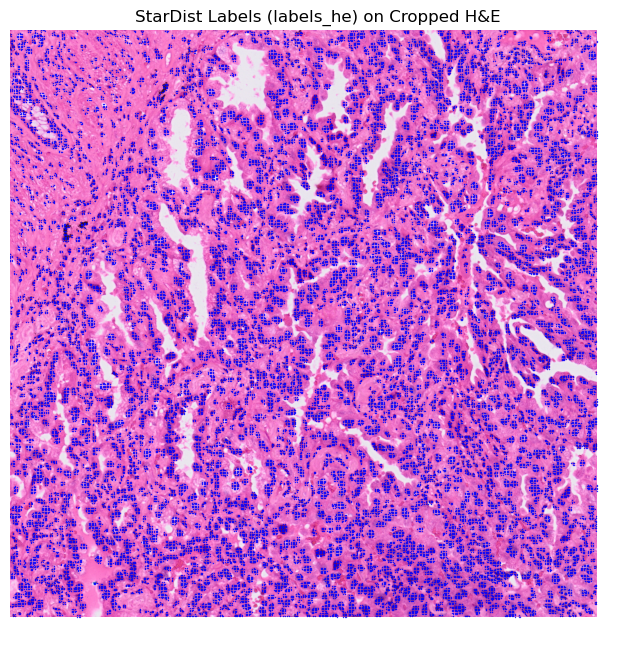

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Grab the cropped image
img = crop_data_segmented.cropped_img

# 2. Pull out the spatial coords and labels from your AnnData
coords = crop_data_segmented.adata.obsm['spatial']    # shape (n_spots, 2): [row, col]
labels = crop_data_segmented.adata.obs['labels_he'].astype(int).values

# 3. (Optional) mask out background spots
mask = labels != 0
coords = coords[mask]
labels = labels[mask]

# 4. Plot
plt.figure(figsize=(8,8))
plt.imshow(img)  # true‐color H&E

# scatter: x=col, y=row; color by label ID
plt.scatter(
    coords[:,0],   # x-axis (column)
    coords[:,1],   # y-axis (row)
    c="blue",      # integer labels
    s=1,           # adjust point size
    linewidth=0,
    alpha=0.8
)

plt.axis('off')
plt.title('StarDist Labels (labels_he) on Cropped H&E')
plt.show()


In [15]:
crop_data_segmented.save(RESULTS_PATH)

[Log]: STCS data saved to /home/xh300/link/spa/newmethod/L=0.5,S=4/gt_crop5


# 3. Pseudobulk Generation

We create pseudobulk data by aggregating gene expression from spots assigned to the same cell.

In [16]:
# load the cropped data so that we could skip the cropping step in future runs
crop_data_segmented = STCS.from_saved(RESULTS_PATH)

[Log]: Loaded cropped image from /home/xh300/link/spa/newmethod/L=0.5,S=4/gt_crop5/cropped_image.tif
[Log]: STCS loaded raw data from /home/xh300/link/spa/newmethod/L=0.5,S=4/gt_crop5: 168691 spots, 18085 genes


In [17]:
crop_data_with_pseudobulk = crop_data_segmented.create_pseudobulk_from_stardist(
    output_path=RESULTS_PATH,
    mode='mean',
)

[Log]: Starting pseudobulk creation from stardist results
[Log]: Loading stardist barcode data
[Log]: Creating pseudobulk based on labels_he
[Log]: Successfully created pseudobulk with 4717 cells and 18085 genes
[Log]: Pseudobulk creation completed
[Log]: Results saved to /home/xh300/link/spa/newmethod/L=0.5,S=4/gt_crop5/pseudobulk


In [18]:
crop_data_with_pseudobulk

In [19]:
crop_data_with_pseudobulk.save(RESULTS_PATH)

[Log]: STCS data saved to /home/xh300/link/spa/newmethod/L=0.5,S=4/gt_crop5


# 4. Parameter Tuning: Search Radius Optimization

We optimize the search radius parameter that determines how far to look for candidate cells when assigning spots.

In [20]:
crop_data_with_pseudobulk = STCS.from_saved(RESULTS_PATH)

[Log]: Loaded cropped image from /home/xh300/link/spa/newmethod/L=0.5,S=4/gt_crop5/cropped_image.tif
[Log]: STCS loaded raw data from /home/xh300/link/spa/newmethod/L=0.5,S=4/gt_crop5: 168691 spots, 18085 genes


## Load the data

In [21]:
barcode_data = crop_data_with_pseudobulk.load_stardist_barcode_data()
adata = crop_data_with_pseudobulk.adata.copy()

# Get detected cells and coordinates
detected = barcode_data[barcode_data.obs['labels_he'] != 0]
detected_coords = detected.obs[['array_row', 'array_col']].values
detected_cells = detected.obs['labels_he'].values
detected_barcodes = detected.obs.index.values

## Test different search radii

In [22]:
coord_to_cell = {}
for i, barcode in enumerate(detected_barcodes):
    coord = tuple(detected_coords[i])
    coord_to_cell[coord] = detected_cells[i]

# Create barcode to own label mapping
barcode_to_own_label = {}
for barcode in detected_barcodes:
    label = detected.obs.loc[barcode, 'labels_he']
    barcode_to_own_label[barcode] = int(label)

print(f"Found {len(barcode_to_own_label)} barcodes with cell labels")

Found 42591 barcodes with cell labels


In [23]:
search_radii = [1, 2, 3, 4, 5]
no_candidates_percentages = []
avg_candidates_per_barcode = []

all_coords = adata.obs[['array_row', 'array_col']].values
all_barcodes = adata.obs.index.values


for search_radius in search_radii:
    print(f"Testing search_radius = {search_radius}")
    
    barcode_candidates = {}
    total_candidates = 0
    
    for idx in range(len(all_barcodes)):
        barcode = all_barcodes[idx]
        row, col = int(all_coords[idx][0]), int(all_coords[idx][1])
        candidate_cells = []
        
        # Add own label if exists
        if barcode in barcode_to_own_label:
            candidate_cells.append(barcode_to_own_label[barcode])
        
        # Search in circular neighborhood
        for dr in range(-search_radius, search_radius + 1):
            for dc in range(-search_radius, search_radius + 1):
                neighbor_coord = (int(row + dr), int(col + dc))
                
                # Check if within circular radius
                distance_sq = dr*dr + dc*dc
                if distance_sq <= search_radius*search_radius and neighbor_coord in coord_to_cell:
                    cell_id = coord_to_cell[neighbor_coord]
                    if cell_id not in candidate_cells:
                        candidate_cells.append(int(cell_id))
        
        barcode_candidates[barcode] = candidate_cells
        total_candidates += len(candidate_cells)
    
    # Calculate statistics
    no_candidates_count = sum(1 for candidates in barcode_candidates.values() if len(candidates) == 0)
    no_candidates_pct = no_candidates_count / len(barcode_candidates) * 100
    avg_candidates = total_candidates / len(barcode_candidates)
    
    no_candidates_percentages.append(no_candidates_pct)
    avg_candidates_per_barcode.append(avg_candidates)
    
    print(f"  - {no_candidates_pct:.2f}% barcodes have no candidates")
    print(f"  - Average {avg_candidates:.1f} candidates per barcode")

Testing search_radius = 1
  - 50.30% barcodes have no candidates
  - Average 0.6 candidates per barcode
Testing search_radius = 2
  - 30.91% barcodes have no candidates
  - Average 1.0 candidates per barcode
Testing search_radius = 3
  - 15.46% barcodes have no candidates
  - Average 1.7 candidates per barcode
Testing search_radius = 4
  - 8.11% barcodes have no candidates
  - Average 2.4 candidates per barcode
Testing search_radius = 5
  - 3.50% barcodes have no candidates
  - Average 3.5 candidates per barcode


## Visualize parameter tuning results

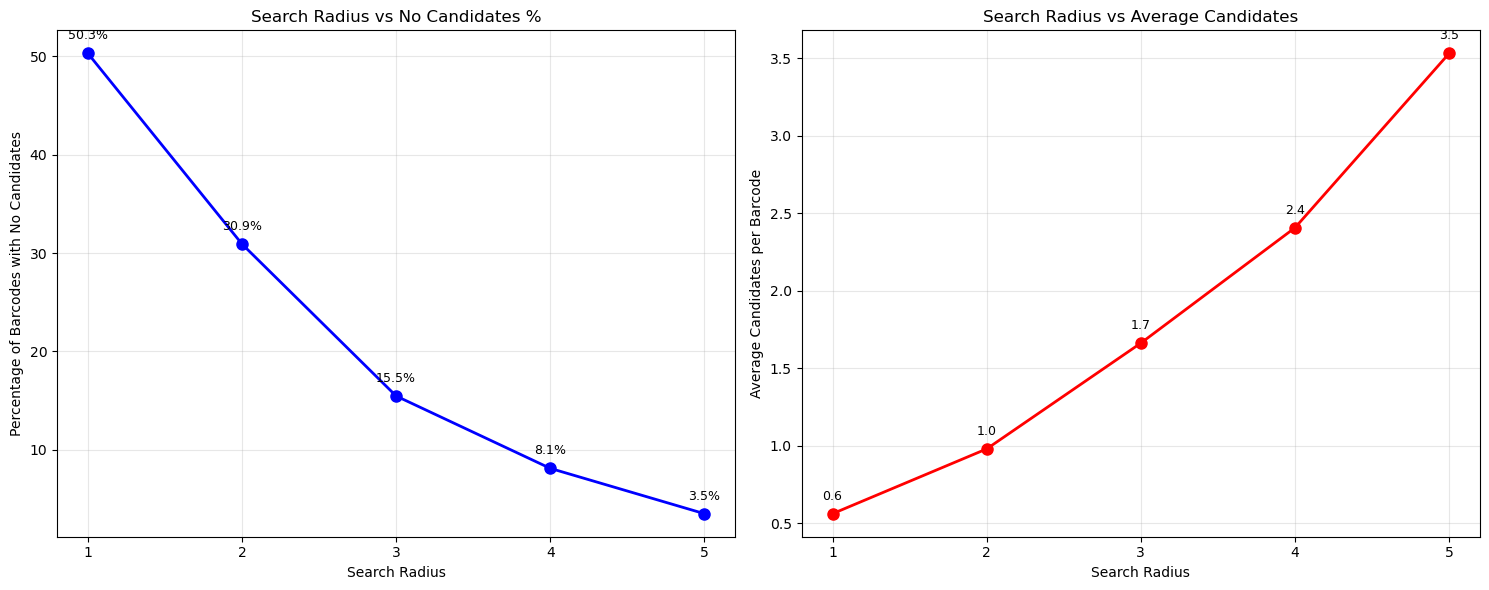

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Percentage of barcodes with no candidates
ax1.plot(search_radii, no_candidates_percentages, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Search Radius')
ax1.set_ylabel('Percentage of Barcodes with No Candidates')
ax1.set_title('Search Radius vs No Candidates %')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(search_radii)

# Add annotations
for i, (r, pct) in enumerate(zip(search_radii, no_candidates_percentages)):
    ax1.annotate(f'{pct:.1f}%', (r, pct), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=9)

# Plot 2: Average candidates per barcode
ax2.plot(search_radii, avg_candidates_per_barcode, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Search Radius')
ax2.set_ylabel('Average Candidates per Barcode')
ax2.set_title('Search Radius vs Average Candidates')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(search_radii)

# Add annotations
for i, (r, avg) in enumerate(zip(search_radii, avg_candidates_per_barcode)):
    ax2.annotate(f'{avg:.1f}', (r, avg), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('radius.pdf', dpi=600,format="pdf", bbox_inches='tight')
plt.show()

# 5. PCA-based Assignment

We perform gene space assignment using PCA to match barcodes to cells based on transcriptomic similarity.

In [25]:
# Use the optimal search radius from parameter tuning
optimal_search_radius = 3  # Use result from parameter tuning or set manually

crop_data_assigned = crop_data_with_pseudobulk.run_assignment(
    output_path=RESULTS_PATH,
    search_radius=optimal_search_radius,
    use_sc_ref=True,  # Use single-cell reference if available
    normalize_distances=True,  # Whether to normalize transcriptomic distances
    feature_name=True  # Whether sc reference uses feature names instead of gene symbols
)

[Log]: Starting assignment pipeline based on candidate search + PCA processing + gene space assignment 
[Log]: Creating barcode to candidate cells mapping
[Log]: Creating barcode candidates mapping with grid search
Stardist - Row: 2490 - 2906
Stardist - Col: 1959 - 2375
[Log]: Found 42591 barcodes with their own labels
Spatial - Row: 2490 - 2906
Spatial - Col: 1959 - 2375
[Log]: Processing grid search (radius=3)
[Log]: Processed 0/168691 barcodes
[Log]: Created candidates mapping for 168691 barcodes
[Log]: Candidates mapping saved to: /home/xh300/link/spa/newmethod/L=0.5,S=4/gt_crop5/integrated_assignment/barcode_candidates.json
[Log]: Loading pseudobulk data
[Log]: Processing with single-cell reference
[Log]: Loading scRNA-seq reference data
[Log]: Processing pseudobulk data
[Log]: Found 4863 common genes
[Log]: Processing spatial adata
[Log]: Projecting 168691 samples to PCA space
[Log]: Processing batch 1/4
[Log]: Processing scRNA-seq reference
[Log]: Computing gene similarity matri

Final assignment: 100%|██████████| 168691/168691 [00:00<00:00, 748974.61it/s]


[Log]: Assigned 142604 barcodes
[Log]: Saving integrated assignment results
[Log]: Assignment is done
[Log]: Results saved to /home/xh300/link/spa/newmethod/L=0.5,S=4/gt_crop5/integrated_assignment


# 6. Cell Type Annotation with CellTypist

We annotate the assigned cells using CellTypist to predict cell types based on gene expression.

In [26]:
crop_data_annotated = crop_data_assigned.run_celltypist_annotation(
    output_path=RESULTS_PATH,
    train_celltypist_model=False
)

[Log]: Starting CellTypist annotation pipeline
[Log]: Creating pseudobulk for CellTypist
[Log]: Starting pseudobulk creation from assignment results
[Log]: Creating pseudobulk based on assigned_cell_id
[Log]: Successfully created pseudobulk with 4717 cells and 18085 genes
[Log]: Pseudobulk creation completed
[Log]: Results saved to /home/xh300/link/spa/newmethod/L=0.5,S=4/gt_crop5/pseudobulk
[Log]: Running CellTypist annotation


2025-09-23 10:52:47 | [INFO] 🔬 Input data has 4717 cells and 18085 genes
2025-09-23 10:52:47 | [INFO] 🔗 Matching reference genes in the model
2025-09-23 10:52:47 | [INFO] 🧬 1713 features used for prediction


[Log]: Using model: /home/xh300/link/spa/sthd/STHD/ground_truth/ref/LungCancerModel.pkl


2025-09-23 10:52:47 | [INFO] ⚖️ Scaling input data
2025-09-23 10:52:47 | [INFO] 🖋️ Predicting labels
2025-09-23 10:52:47 | [INFO] ✅ Prediction done!
2025-09-23 10:52:47 | [INFO] 👀 Can not detect a neighborhood graph, will construct one before the over-clustering
2025-09-23 10:52:54 | [INFO] ⛓️ Over-clustering input data with resolution set to 5
2025-09-23 10:52:54 | [INFO] 🗳️ Majority voting the predictions
2025-09-23 10:52:54 | [INFO] ✅ Majority voting done!


[Log]: Saving annotated results
[Log]: Merging back column: predicted_labels
[Log]: Merging back column: over_clustering
[Log]: Merging back column: majority_voting
[Log]: Merging back column: conf_score


... storing 'assigned_cell_id' as categorical
... storing 'celltypist_predicted_labels' as categorical
... storing 'celltypist_over_clustering' as categorical
... storing 'celltypist_majority_voting' as categorical
... storing 'celltypist_conf_score' as categorical


[Log]: CellTypist annotation completed
[Log]: Results saved to /home/xh300/link/spa/newmethod/L=0.5,S=4/gt_crop5/celltypist_annotation


# 7. Visualization

We create spatial visualizations of the annotated cell types.

In [27]:
annotated_adata = crop_data_annotated.adata.copy()

In [28]:
annotated_adata.obs

,in_tissue,array_row,array_col,labels_he,assigned_cell_id,celltypist_predicted_labels,celltypist_over_clustering,celltypist_majority_voting,celltypist_conf_score
s_002um_02503_02060-1,1,2503,2060,3469,3469,epithelial cell,7,epithelial cell,0.07410933674182849
s_002um_02842_01969-1,1,2842,1969,0,1066,epithelial cell,77,epithelial cell,0.13603961740767503
s_002um_02668_02292-1,1,2668,2292,0,3791,epithelial cell,1,epithelial cell,0.7023208875499353
s_002um_02538_02168-1,1,2538,2168,3621,3621,epithelial cell,65,epithelial cell,0.03691633066678541
s_002um_02805_02363-1,1,2805,2363,0,2546,epithelial cell,82,epithelial cell,0.6885553722224467
...,...,...,...,...,...,...,...,...,...
s_002um_02823_02046-1,1,2823,2046,0,1292,epithelial cell,101,epithelial cell,0.5609995163439896
s_002um_02859_02152-1,1,2859,2152,1616,1616,epithelial cell,86,epithelial cell,0.9144072960999953
s_002um_02702_02213-1,1,2702,2213,0,56,epithelial cell,88,epithelial cell,0.989805842421926
s_002um_02515_02262-1,1,2515,2262,0,None,undefined,undefined,undefined,undefined


In [29]:
# fill nan with filtered
annotated_adata.obs["celltypist_predicted_labels"] = annotated_adata.obs["celltypist_predicted_labels"].astype('str')
annotated_adata.obs["celltypist_predicted_labels"] = annotated_adata.obs["celltypist_predicted_labels"].replace("nan", "undefined")
annotated_adata = annotated_adata[annotated_adata.obs["celltypist_predicted_labels"] != 'undefined']

In [30]:
annotated_adata.obs["celltypist_predicted_labels"].value_counts()

celltypist_predicted_labels
epithelial cell          108249
malignant cell            21275
B cell                     7906
fibroblast                 2618
mononuclear phagocyte      1078
endothelial cell           1053
T cell                      425
Name: count, dtype: int64

In [31]:
cmap = {
    'B cell': '#7A57D1',
    'endothelial cell': '#FF731D',
    'epithelial cell': '#bc8420',
    'fibroblast': '#CF0A0A',
    'malignant cell': '#83FFE6',
    'mast cell': '#0000A1',
    'megakaryocyte': '#fff568',
    'mononuclear phagocyte': '#0080ff',
    'neutrophil': '#81C6E8',
    'plasmacytoid dendritic cell': '#385098',
    'T cell': '#ffb5ba',
    'ambiguous': '#d3d3d3',
    'filtered': '#848884'
}


cmap_rep2 = {
    'EC -villi base': '#1f77b4',
    'EC': '#ff7f0e',
    'EC-TA': '#2ca02c',
    'Progenitor': '#d62728',
    'Tuft': '#00FF7F',
    'B cell': '#2E8B57',
    'Endothelial': '#e377c2',
    'Goblet': '#7f7f7f',
    'Villi tip': '#bcbd22',
    'T cell': '#17becf',
    'TA': '#98FB98',
    'Paneth cell': "#730fec",
    'Mesenchyme': '#7570b3',
    'EEC':"#984ea3",
    'SC':"#708090",
    'Myeloid-macrophage':"#ffff33",
    'Microglial-macrophage':"#a65628",
}

In [32]:
#from config import colormap_lung_ct_group

from matplotlib.colors import ListedColormap
data_cmap = []
for p in sorted(list(set(annotated_adata.obs['celltypist_predicted_labels']))):
    if p == 'undefined':
        cur_color = 'white'
    else:
        cur_color = cmap[p]
    data_cmap.append(cur_color)
palette = ListedColormap(data_cmap)


## Squidpy plot

... storing 'celltypist_predicted_labels' as categorical


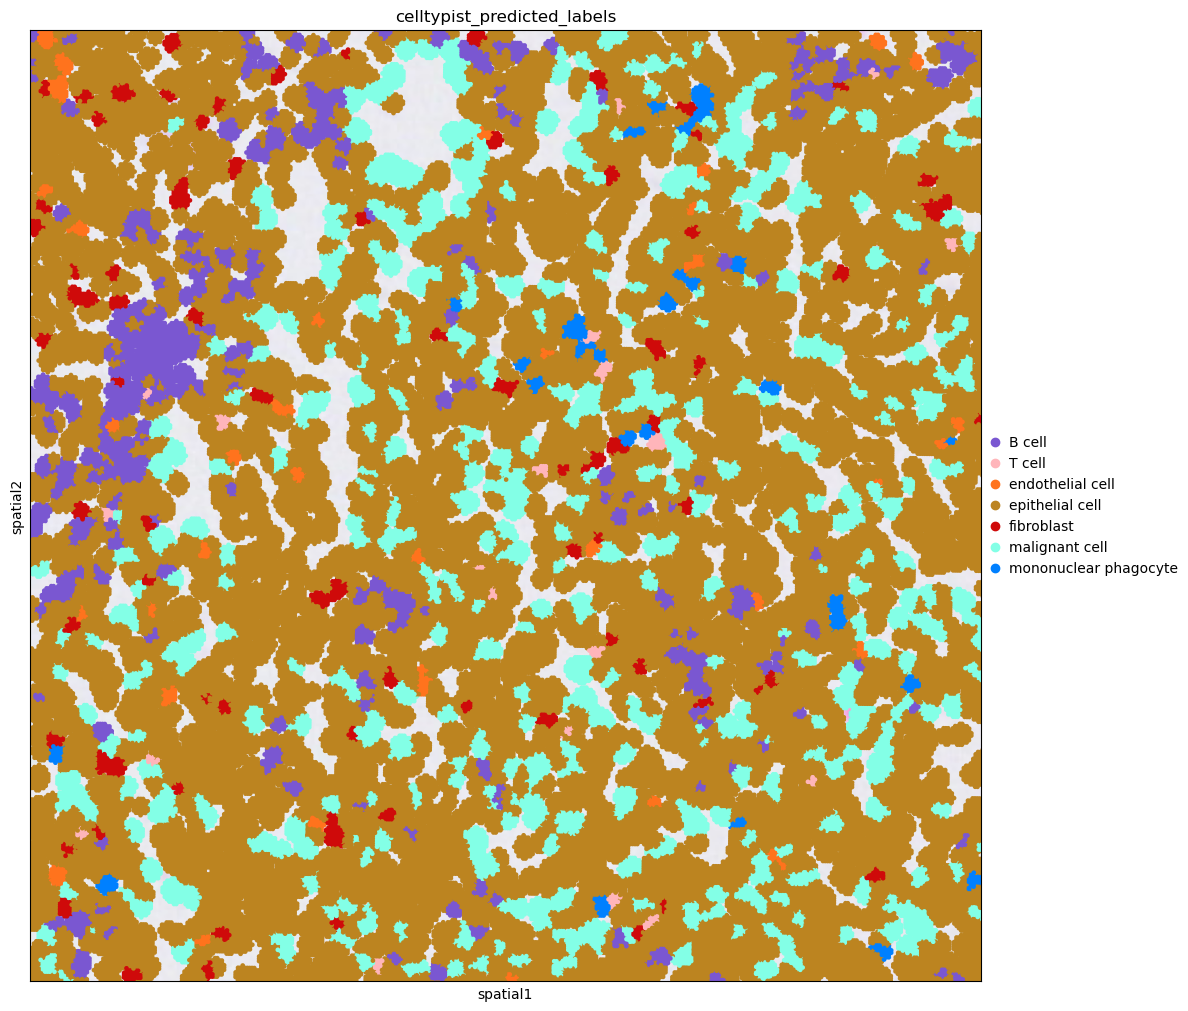

In [33]:
import squidpy as sq

sq.pl.spatial_scatter(
    annotated_adata,
    color = 'celltypist_predicted_labels',
    crop_coord = (crop_data_annotated.crop_coords['aligned_x1'],
                  crop_data_annotated.crop_coords['aligned_y1'],
                  crop_data_annotated.crop_coords['aligned_x2'],
                  crop_data_annotated.crop_coords['aligned_y2']),
    figsize = (25,10),
    size = 2,
    palette = palette
)

In [ ]:
fg[fg['cells']==float(3755.0)].index

Index([     0,   8298,   8445,  10951,  11488,  21904,  28651,  31895,  38828,
        39726,  42857,  62217,  65633,  70074,  70185,  87175,  89795,  96317,
       106149, 109042, 111706, 112334, 126055, 133138, 133660, 139378, 142161,
       142561, 145682],
      dtype='int64')

In [89]:
fg

,barcode,cells
0,s_002um_00397_02086-1,3755.0
1,s_002um_00186_02129-1,4355.0
2,s_002um_00126_02178-1,NaN
3,s_002um_00460_02129-1,2896.0
4,s_002um_00144_02152-1,288.0
...,...,...
158447,s_002um_00176_02097-1,2653.0
158448,s_002um_00115_02156-1,3031.0
158449,s_002um_00358_02392-1,4112.0
158450,s_002um_00296_02357-1,2092.0


100%|██████████| 4471/4471 [00:00<00:00, 4906.26it/s]


gt_crop1
0.9997528230362047


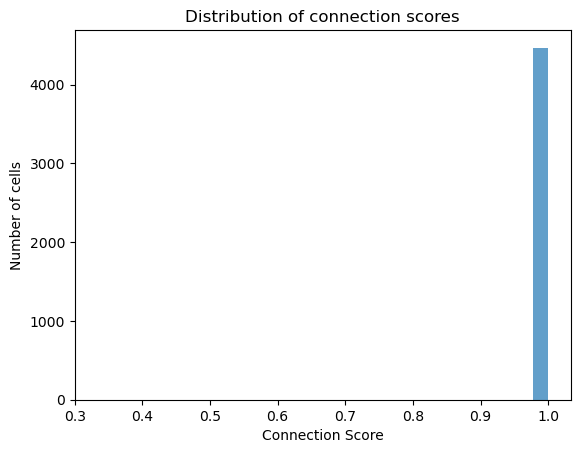

100%|██████████| 4350/4350 [00:01<00:00, 4072.83it/s]


gt_crop2
0.9998928754364862


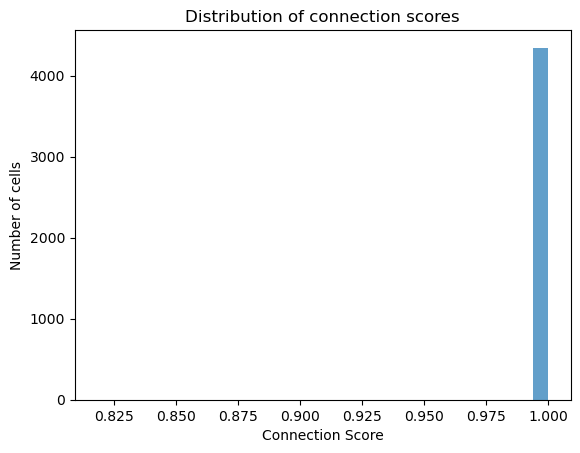

100%|██████████| 3515/3515 [00:00<00:00, 3550.33it/s]


gt_crop3
0.9997156352419511


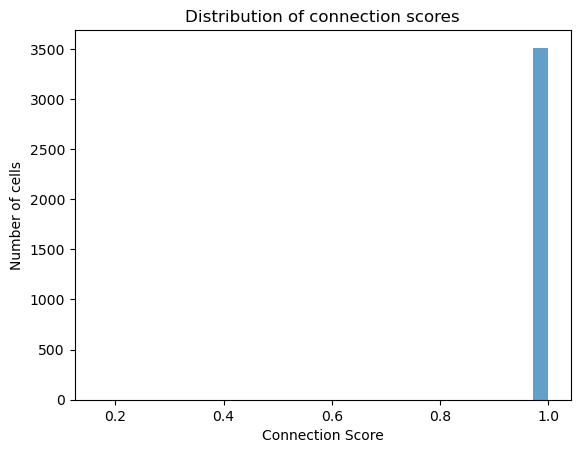

100%|██████████| 4525/4525 [00:00<00:00, 4719.77it/s]


gt_crop4
0.9998647245940063


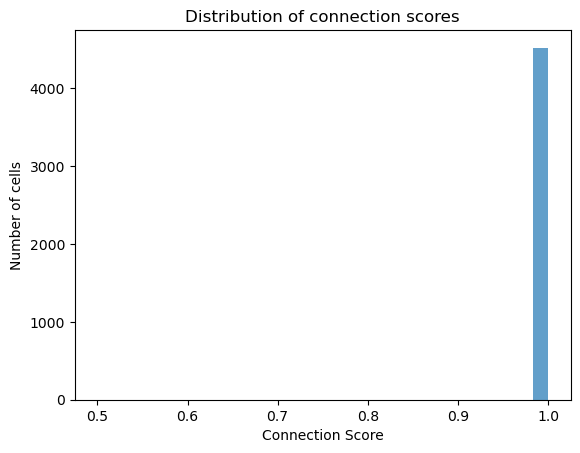

100%|██████████| 4715/4715 [00:01<00:00, 4141.48it/s]


gt_crop5
0.9997909930492116


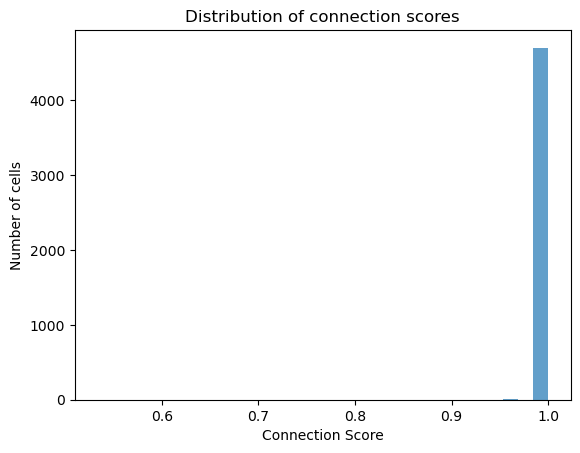

In [98]:
import numpy as np
import pandas as pd
import networkx as nx
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from tqdm import tqdm
from anndata import AnnData

def get_array_cor(cor):
    dic = {}
    cor['array'] = [(int(i.split('_')[3][:-2]),int(i.split('_')[2])) for i in cor['barcode']]
    for i in tqdm(cor['cell_id'].unique()):
        dic[i] = list(cor[cor['cell_id']==i]['array'])
    return(dic)

import numpy as np
import pandas as pd
import networkx as nx

# -------- Step 1: 定义邻接规则 --------
def get_adjacent_coords(coord, mode="4"):
    """
    给定 (row, col)，返回相邻的格点坐标
    mode="4" → 上下左右
    mode="8" → 上下左右 + 四个对角线
    """
    r, c = coord
    neighbors = [
        (r-1, c), (r+1, c),   # 上下
        (r, c-1), (r, c+1)    # 左右
    ]
    if mode == "8":
        neighbors += [
            (r-1, c-1), (r-1, c+1),  # 左上、右上
            (r+1, c-1), (r+1, c+1)   # 左下、右下
        ]
    return neighbors

# -------- Step 2: 计算单个cell的connection score --------
def connection_score_grid(barcodes_coords, mode="8"):
    """
    输入: barcodes_coords = [(row1,col1), (row2,col2), ...]
    输出: connection score in [0,1]
    """
    if len(barcodes_coords) <= 1:
        return 1.0
    
    coord_set = set(map(tuple, barcodes_coords))
    G = nx.Graph()
    for coord in coord_set:
        G.add_node(coord)
        for nb in get_adjacent_coords(coord, mode=mode):
            if nb in coord_set:
                G.add_edge(coord, nb)
    
    # 找最大连通子图
    largest_cc = max(nx.connected_components(G), key=len)
    score = len(largest_cc) / len(coord_set)
    return score

# -------- Step 3: 批量处理所有cells --------
def compute_connection_scores(cell2coords, mode="8"):
    """
    cell2coords: dict {cell_id: [(row,col), (row,col), ...]}
    返回: DataFrame, 每个cell的connection_score
    """
    results = []
    for cell_id, coords in tqdm(cell2coords.items()):
        score = connection_score_grid(coords, mode=mode)
        results.append([cell_id, score])
    return pd.DataFrame(results, columns=["cell_id","connection_score"])

def plot_connection_score_hist(df_scores):
    plt.hist(df_scores["connection_score"].dropna(), bins=30, alpha=0.7)
    plt.xlabel("Connection Score")
    plt.ylabel("Number of cells")
    plt.title("Distribution of connection scores")
    plt.show()

def process(ndata:AnnData):
    #sc.pp.filter_cells(ndata, min_genes=100)
    #sc.pp.filter_genes(ndata, min_cells=3)
    sc.pp.normalize_total(ndata)
    sc.pp.log1p(ndata)
    sc.pp.highly_variable_genes(ndata, n_top_genes=2000)
    sc.pp.scale(ndata)
    sc.tl.pca(ndata)
    sc.pp.neighbors(ndata)
    sc.tl.leiden(ndata, n_iterations=2,resolution=0.5)
    sc.tl.umap(ndata)
for folder in ['gt_crop1','gt_crop2','gt_crop3','gt_crop4','gt_crop5']:
    ofolder = '/home/xh300/link/spa/newmethod/L=0.5,S=3/' + folder
    odata = sc.read_h5ad(ofolder + '/celltypist_annotation/annotated_cells.h5ad')
    jj = pd.DataFrame(odata.obs)
    jj = jj[jj.index != 'None']
    fg = pd.read_csv(ofolder +'/integrated_assignment/final_assignments.csv')
    pos = pd.read_csv('/home/xh300/link/spa/spaceranger/Ground_Truth_10x/outs/segmented_outputs/spatial/tissue_positions.csv')

    pos.index = pos['barcode']
    from tqdm import tqdm
    f = open("/home/xh300/link/spa/newmethod/gt_connection/gt_cor.csv", "w")
    f.write(',cell_id,barcode,y,x'+'\n')
    n = 0
    for i in tqdm(jj.index):
        for k in fg[fg['cells']==float(i)]['barcode']:
            f.write(str(n)+','+str(i)+'.0,'+k+','+str(pos.loc[k]['pxl_row_in_fullres'])+','+str(pos.loc[k]['pxl_col_in_fullres'])+'\n')
            n+=1
    o = pd.read_csv('/home/xh300/link/spa/newmethod/gt_connection/gt_cor.csv')
    d = get_array_cor(o)
    o_score = compute_connection_scores(d, mode="8")
    print(folder)
    print(np.mean(o_score['connection_score']))
    plot_connection_score_hist(o_score)

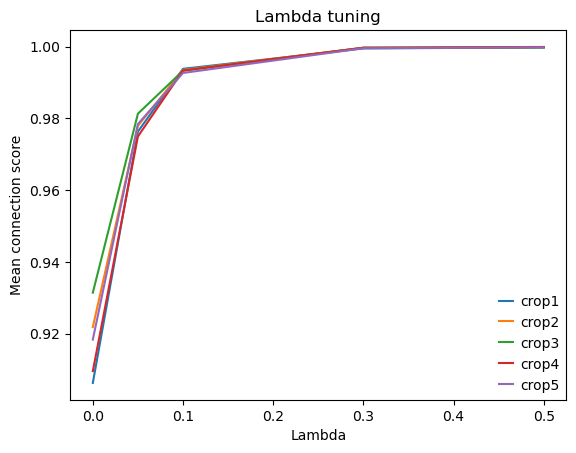

In [ ]:
import matplotlib.pyplot as plt

# 假设有三组数据
x = [0, 0.05, 0.1, 0.3, 0.5]
y1 = [0.9062593985086259,0.9763038472386515,0.9937928485525276,0.9994712101739401,0.9997528230362047]
y2 = [0.9218198030965057,0.9779222656910208,0.993487959603041,0.9996656686857115,0.9998928754364862]
y3 = [0.9314096206072703,0.9812954062623809,0.9932468721023413,0.9996656686857115,0.9997156352419511]
y4 = [0.9095551878192271,0.974937841721099,0.9933196594236003,0.9996601890142459,0.9998647245940063]
y5 = [0.9183358969794948,0.9784003797965932,0.9926381825574716,0.9995314075693549,0.9997909930492116]
#y3 = [3, 5, 7, 9, 13]
colors = ["red", "blue", "green", "orange", "purple"]
# 分别调用多次 plt.plot
plt.plot(x, y1, label="crop1",color = 'red')
plt.plot(x, y2, label="crop2",color = 'blue')
plt.plot(x, y3, label="crop3",color = 'green')
plt.plot(x, y4, label="crop4",color = 'orange')
plt.plot(x, y5, label="crop5",color = 'purple')
#plt.plot(x, y3, label="crop3", marker="^")

# 添加图例
plt.legend()
plt.xlabel("Lambda")
plt.ylabel("Mean connection score")
plt.title("Lambda tuning")
plt.show()

In [52]:
def plot_spatial_celltypes(adata, cmap, title="Interactive Spatial Plot", 
                          width=1000, height=800, point_size=10, save_path=None):
    """
    Interactive visualization of spatial cell types using Plotly WebGL.
    """
    
    # Extract and clean data
    obs_df = adata.obs[['array_row', 'array_col', 'celltypist_predicted_labels']].copy()
    obs_df = obs_df.dropna().reset_index(drop=True)
    
    # Get unique cell types and create color mapping
    cell_types = sorted(obs_df['celltypist_predicted_labels'].unique())
    colors = [cmap.colors[i] for i in range(len(cell_types))]
    
    # Convert colors to hex format
    hex_colors = []
    for color in colors:
        if isinstance(color, (tuple, list, np.ndarray)):
            if len(color) >= 3:
                r, g, b = color[:3]
                if max(r, g, b) <= 1.0:
                    r, g, b = int(r*255), int(g*255), int(b*255)
                hex_color = f"#{r:02x}{g:02x}{b:02x}"
            else:
                hex_color = "#808080"
        else:
            hex_color = str(color)
        hex_colors.append(hex_color)
    
    # Create color mapping
    color_map = dict(zip(cell_types, hex_colors))
    obs_df['color'] = obs_df['celltypist_predicted_labels'].map(color_map)
    
    # Create figure
    fig = go.Figure()
    
    # Add traces for each cell type (enables legend interaction)
    for i, cell_type in enumerate(cell_types):
        mask = obs_df['celltypist_predicted_labels'] == cell_type
        subset = obs_df[mask]
        
        fig.add_trace(
            go.Scattergl(  # WebGL for performance
                x=subset['array_col'],
                y=subset['array_row'],
                mode='markers',
                marker=dict(
                    color=hex_colors[i],
                    size=point_size/4,  # Adjust size for WebGL
                    line=dict(width=0)
                ),
                name=cell_type,
                customdata=np.column_stack((subset['celltypist_predicted_labels'],)),
                hovertemplate='<b>%{customdata[0]}</b><br>' +
                             'Row: %{y}<br>' +
                             'Col: %{x}<br>' +
                             '<extra></extra>',
                legendgroup=cell_type
            )
        )
    
    # Update layout
    fig.update_layout(
        title=dict(text=title, x=0.5),
        xaxis_title="Array Column",
        yaxis_title="Array Row",
        width=width,
        height=height,
        showlegend=True,
        legend=dict(
            title="Cell Types (Click to highlight)",
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=1.01,
            itemclick="toggleothers", 
            itemdoubleclick="toggle", 
            itemsizing="constant"
        ),
        hovermode='closest',
        plot_bgcolor='white'
    )
    
    # Update axes
    fig.update_xaxes(title="Array Column")
    fig.update_yaxes(title="Array Row")
    
    # Save
    if save_path:
        if save_path.endswith('.html'):
            fig.write_html(save_path)
        else:
            fig.write_html(f"{save_path}/interactive_spatial_plot.html")
        print(f"Visualization saved to {save_path}")
    
    return fig

In [53]:
chart = plot_spatial_celltypes(annotated_adata,palette,save_path=RESULTS_PATH)

Visualization saved to /home/xh300/link/spa/newmethod/gt_connection
